In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.special import gamma
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

Solving kurtosis grid ...
  Converged: 100/100  | Lambda range: [0.239, 2.000]
Solving skewness grid ...
  Converged: 81/81  | Alpha range: [0.0923, 0.9077]
  Lambda used: [np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.8), np.float64(1.2), np.float64(1.5), np.float64(2.0)]
  Implied kurtosis range: [3.00, 2376.22]


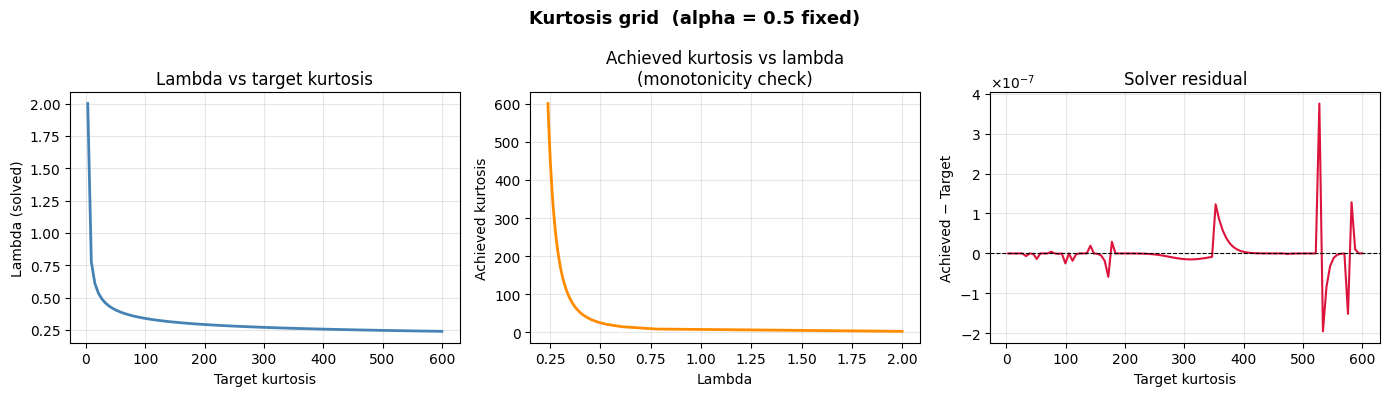

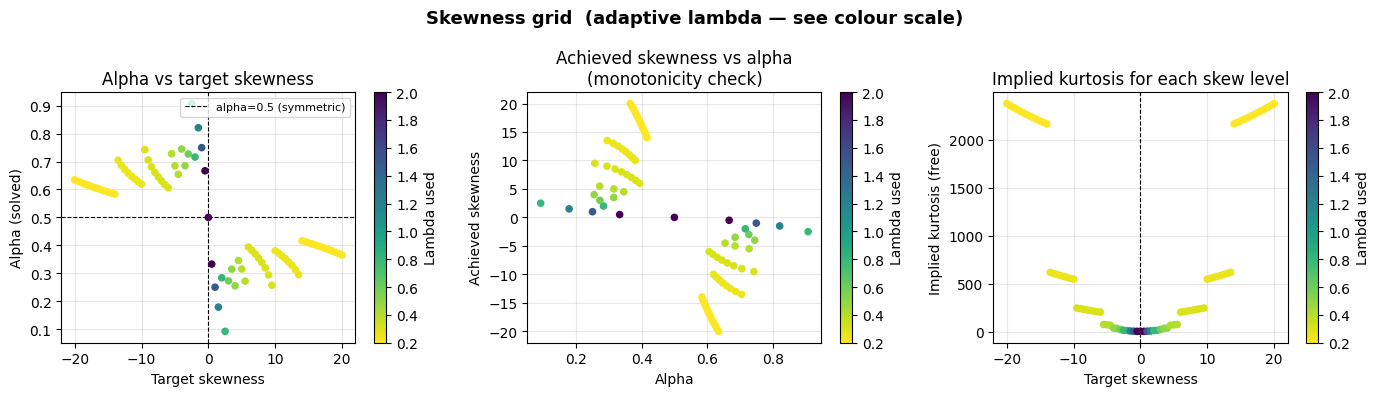

,target_skew,lam,alpha,achieved_skew,achieved_kurt,converged


In [ ]:

# %% Parameters — edit freely
SKEW_GRID  = np.linspace(-20.0, 20.0, 81)   # target skewness values
KURT_GRID  = np.linspace(3.0, 600.0, 100)   # target kurtosis values
                                              # (raw 4th standardised moment; 3 = Normal)

ALPHA_KURTOSIS = 0.5    # fixed alpha for the kurtosis grid (symmetric)

# Skewness solver: for each target we try lambdas in descending order and
# use the first one for which brentq brackets a sign change on alpha.
# Smaller lambda → heavier tails → wider achievable |skew| range.
LAMBDA_LADDER = [2.0, 1.5, 1.2, 1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.25, 0.2]

# Solver search bounds
ALPHA_BOUNDS  = (1e-4, 1 - 1e-4)   # alpha ∈ (0, 1)
LAMBDA_BOUNDS = (0.15, 6.0)        # lambda > 0; small λ → heavy tails → high kurt

# %% APD moment engine (reused from Komunjer / user code)

def _delta(alpha: float, lam: float) -> float:
    """Scale constant δ of the APD."""
    num = 2.0 * (alpha ** lam) * ((1.0 - alpha) ** lam)
    den = (alpha ** lam) + ((1.0 - alpha) ** lam)
    return num / den


def raw_moment(k: int, alpha: float, lam: float) -> float:
    """k-th raw moment of the APD(alpha, lambda)."""
    d   = _delta(alpha, lam)
    M_k = (1.0 - alpha) ** (k + 1) + ((-1) ** k) * (alpha ** (k + 1))
    G_k = gamma((k + 1) / lam) / (d ** (k / lam) * gamma(1.0 / lam))
    return G_k * M_k


def apd_moments(alpha: float, lam: float) -> tuple[float, float]:
    """
    Returns (skewness, kurtosis) for APD(alpha, lambda).
    Kurtosis here is the standardised 4th central moment (= 3 for Normal).
    """
    m1, m2, m3, m4 = (raw_moment(k, alpha, lam) for k in range(1, 5))

    var  = m2 - m1 ** 2
    sd   = np.sqrt(var)
    mu3  = m3 - 3 * m1 * m2 + 2 * m1 ** 3
    mu4  = m4 - 4 * m1 * m3 + 6 * m1 ** 2 * m2 - 3 * m1 ** 4

    skew = mu3 / sd ** 3
    kurt = mu4 / sd ** 4          # raw kurtosis (3 = Normal)
    return skew, kurt

# %% Kurtosis grid solver
# alpha = 0.5 fixed; find lambda such that kurtosis(0.5, lambda) = target_kurt

def _kurt_residual_kurtgrid(lam: float, target_kurt: float) -> float:
    _, k = apd_moments(ALPHA_KURTOSIS, lam)
    return k - target_kurt


def solve_lambda_for_kurt(target_kurt: float) -> dict:
    """
    Find lambda ∈ LAMBDA_BOUNDS such that APD(0.5, lambda) has the
    desired kurtosis.  Returns a result dict with keys:
        target_kurt, alpha, lam, achieved_skew, achieved_kurt, converged
    """
    result = dict(target_kurt=target_kurt, alpha=ALPHA_KURTOSIS,
                  lam=np.nan, achieved_skew=np.nan,
                  achieved_kurt=np.nan, converged=False)
    try:
        lo, hi = LAMBDA_BOUNDS
        f_lo = _kurt_residual_kurtgrid(lo, target_kurt)
        f_hi = _kurt_residual_kurtgrid(hi, target_kurt)
        if f_lo * f_hi > 0:
            # No sign change → target outside achievable range for these bounds
            return result
        lam_opt = brentq(_kurt_residual_kurtgrid, lo, hi,
                         args=(target_kurt,), xtol=1e-10, rtol=1e-10)
        skew_a, kurt_a = apd_moments(ALPHA_KURTOSIS, lam_opt)
        result.update(lam=lam_opt, achieved_skew=skew_a,
                      achieved_kurt=kurt_a, converged=True)
    except Exception:
        pass
    return result


print("Solving kurtosis grid ...")
kurt_records = [solve_lambda_for_kurt(k) for k in KURT_GRID]
kurt_df = pd.DataFrame(kurt_records)
n_ok  = kurt_df["converged"].sum()
print(f"  Converged: {n_ok}/{len(kurt_df)}  "
      f"| Lambda range: [{kurt_df['lam'].min():.3f}, {kurt_df['lam'].max():.3f}]")

# %% Skewness grid solver — adaptive lambda ladder
#
# For a fixed lambda, the achievable skewness range when alpha sweeps (0,1)
# is bounded: smaller lambda → heavier tails → wider range.
# Strategy: for each target skew, walk down LAMBDA_LADDER and use the first
# lambda for which brentq finds a sign change on alpha.
# Alpha still drives the sign and magnitude; lambda is a nuisance parameter
# chosen purely to make the root findable.

def _skew_residual(alpha: float, lam: float, target_skew: float) -> float:
    s, _ = apd_moments(alpha, lam)
    return s - target_skew


def solve_alpha_for_skew(target_skew: float) -> dict:
    """
    Find (alpha, lambda) such that APD(alpha, lambda) has skewness = target_skew.

    Walks down LAMBDA_LADDER; for each lambda tries brentq on alpha ∈ ALPHA_BOUNDS.
    Returns on the first lambda that brackets a sign change (largest lambda that
    works → lightest feasible tails for the given target).
    Kurtosis is unconstrained (free).

    Keys: target_skew, lam, alpha, achieved_skew, achieved_kurt, converged
    """
    result = dict(target_skew=target_skew, lam=np.nan, alpha=np.nan,
                  achieved_skew=np.nan, achieved_kurt=np.nan, converged=False)

    lo, hi = ALPHA_BOUNDS
    for lam in LAMBDA_LADDER:
        try:
            f_lo = _skew_residual(lo, lam, target_skew)
            f_hi = _skew_residual(hi, lam, target_skew)
            if f_lo * f_hi > 0:
                # No sign change for this lambda → try next (smaller) one
                continue
            alpha_opt = brentq(_skew_residual, lo, hi,
                               args=(lam, target_skew),
                               xtol=1e-10, rtol=1e-10)
            skew_a, kurt_a = apd_moments(alpha_opt, lam)
            result.update(lam=lam, alpha=alpha_opt, achieved_skew=skew_a,
                          achieved_kurt=kurt_a, converged=True)
            return result          # found — stop at largest feasible lambda
        except Exception:
            continue               # numerical issue; try next lambda

    return result                  # all lambdas exhausted without convergence


print("Solving skewness grid ...")
skew_records = [solve_alpha_for_skew(s) for s in SKEW_GRID]
skew_df = pd.DataFrame(skew_records)
n_ok = skew_df["converged"].sum()
print(f"  Converged: {n_ok}/{len(skew_df)}  "
      f"| Alpha range: [{skew_df['alpha'].min():.4f}, {skew_df['alpha'].max():.4f}]")
print(f"  Lambda used: {sorted(skew_df['lam'].dropna().unique())}")
print(f"  Implied kurtosis range: "
      f"[{skew_df['achieved_kurt'].min():.2f}, {skew_df['achieved_kurt'].max():.2f}]")

# %% Plot — Kurtosis grid
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    f"Kurtosis grid  (alpha = {ALPHA_KURTOSIS} fixed)",
    fontsize=13, fontweight="bold"
)

df_ok = kurt_df[kurt_df["converged"]]

ax = axes[0]
ax.plot(df_ok["target_kurt"], df_ok["lam"], color="steelblue", lw=2)
ax.set_xlabel("Target kurtosis")
ax.set_ylabel("Lambda (solved)")
ax.set_title("Lambda vs target kurtosis")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_ok["lam"], df_ok["achieved_kurt"], color="darkorange", lw=2)
ax.plot(df_ok["lam"], df_ok["lam"] * 0 + df_ok["target_kurt"].iloc[0],
        lw=0)          # invisible anchor so axis scales properly
ax.set_xlabel("Lambda")
ax.set_ylabel("Achieved kurtosis")
ax.set_title("Achieved kurtosis vs lambda\n(monotonicity check)")
ax.grid(True, alpha=0.3)

ax = axes[2]
error = df_ok["achieved_kurt"] - df_ok["target_kurt"]
ax.plot(df_ok["target_kurt"], error, color="crimson", lw=1.5)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Target kurtosis")
ax.set_ylabel("Achieved − Target")
ax.set_title("Solver residual")
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %% Plot — Skewness grid
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    "Skewness grid  (adaptive lambda — see colour scale)",
    fontsize=13, fontweight="bold"
)

df_ok = skew_df[skew_df["converged"]].copy()

# Colour points by the lambda that was selected
lam_vals = df_ok["lam"].values
norm      = plt.Normalize(lam_vals.min(), lam_vals.max())
cmap      = plt.cm.viridis_r           # darker = smaller lambda = heavier tails

ax = axes[0]
sc = ax.scatter(df_ok["target_skew"], df_ok["alpha"],
                c=lam_vals, cmap=cmap, norm=norm, s=20, zorder=3)
ax.axvline(0,   color="black", lw=0.8, ls="--")
ax.axhline(0.5, color="black", lw=0.8, ls="--", label="alpha=0.5 (symmetric)")
ax.set_xlabel("Target skewness")
ax.set_ylabel("Alpha (solved)")
ax.set_title("Alpha vs target skewness")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="Lambda used")

ax = axes[1]
sc = ax.scatter(df_ok["alpha"], df_ok["achieved_skew"],
                c=lam_vals, cmap=cmap, norm=norm, s=20, zorder=3)
ax.set_xlabel("Alpha")
ax.set_ylabel("Achieved skewness")
ax.set_title("Achieved skewness vs alpha\n(monotonicity check)")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="Lambda used")

ax = axes[2]
sc = ax.scatter(df_ok["target_skew"], df_ok["achieved_kurt"],
                c=lam_vals, cmap=cmap, norm=norm, s=20, zorder=3)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Target skewness")
ax.set_ylabel("Implied kurtosis (free)")
ax.set_title("Implied kurtosis for each skew level")
ax.grid(True, alpha=0.3)
fig.colorbar(sc, ax=ax, label="Lambda used")

plt.tight_layout()
plt.show()

# %% Quick summary tables
kurt_df[kurt_df.converged==False]
skew_df[skew_df.converged==False]

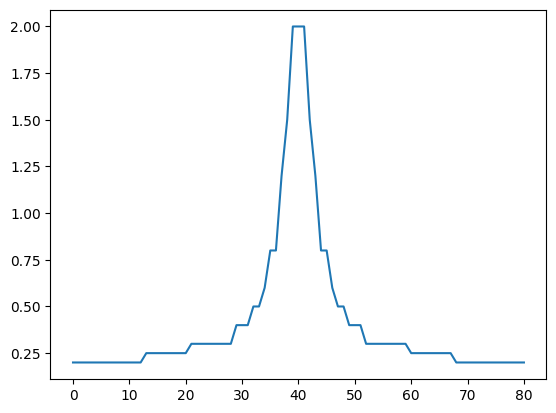

In [15]:
plt.plot(skew_df.lam)

In [44]:
kurt_df

,target_kurt,alpha,lam,achieved_skew,achieved_kurt,converged
0,3.000000,0.5,2.000000,0.0,3.000000,True
1,9.030303,0.5,0.777016,0.0,9.030303,True
2,15.060606,0.5,0.608576,0.0,15.060606,True
3,21.090909,0.5,0.532838,0.0,21.090909,True
4,27.121212,0.5,0.487605,0.0,27.121212,True
...,...,...,...,...,...,...
95,575.878788,0.5,0.240527,0.0,575.878788,True
96,581.909091,0.5,0.240113,0.0,581.909091,True
97,587.939394,0.5,0.239705,0.0,587.939394,True
98,593.969697,0.5,0.239302,0.0,593.969697,True


In [ ]:
skew_df.iloc[10:20]

In [45]:
from core.dgp import APDInnov, IIDProcess

m = IIDProcess(APDInnov(alpha=0.5, lam=0.238905)).calibrate_params(mu=0.15, sigma=1.0)

In [46]:
m.get_theo_moments()

{'skew': np.float64(0.0),
 'exc_kurt': np.float64(596.9957813845961),
 'rho': 0,
 'nu': 0.0,
 'mean': 0.15,
 'sigma': 1.0}

In [47]:
rng = np.random.default_rng(42)
sample = m.simulate(100000, rng)

In [48]:
from scipy import stats

stats.kurtosis(sample, fisher=False,),stats.skew(sample)

(np.float64(383.07955718957624), np.float64(-0.32909081380797395))

In [65]:
MEAN_GRID  = np.linspace(0.0, 5.0, 81)
STD_GRID  = np.linspace(0.0, 5.0, 81)

In [66]:
mean_df = pd.DataFrame([dict(target_mean=mean, lam=2, alpha=0.5, achieved_mean=mean, converged=True) 
                        for mean in MEAN_GRID])
std_df = pd.DataFrame([dict(target_std=std, lam=2, alpha=0.5, achieved_std=std, converged=True) 
                        for std in STD_GRID])


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import warnings

In [68]:

import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
warnings.filterwarnings("ignore")

SEED        = 42
N_SIMS      = 1000
T           = 252 

_SAMPLE_ESTIMATORS = {
    "mean": lambda x: np.mean(x),
    "std": lambda x: np.std(x, ddof=1),
    "skew": lambda x: scipy_stats.skew(x, bias=False),
    "kurt": lambda x: scipy_stats.kurtosis(x, fisher=False, bias=False),  # raw kurt
}
_TARGET_COLS = {
    "mean": "target_mean",
    "std":  "target_std",
    "skew": "target_skew",
    "kurt": "target_kurt",
}
 
 
def simulate_panel(
    param:  str,                  # "skew" or "kurt"
    grid_df: pd.DataFrame,        # skew_df or kurt_df (converged rows only)
    n_sims: int = N_SIMS,
    T:      int = T,
    seed:   int = SEED,
) -> pd.DataFrame:
    """
    For every (alpha, lam) row in grid_df, draw n_sims independent samples
    of length T from APD(alpha, lam) and compute the sample moment estimator.
 
    Parameters
    ----------
    param    : which moment to study — "skew" or "kurt"
    grid_df  : parameter grid DataFrame (output of solve_* functions,
               filtered to converged=True).  Must contain columns
               'alpha', 'lam', and the relevant target column.
    n_sims   : number of Monte-Carlo replications per grid point
    T        : sample length for each replication
    seed     : RNG seed
 
    Returns
    -------
    Tidy DataFrame with columns:
        sim_id          replication index
        true_mom        true (population) value of the moment
        sample_mom      sample estimator value
        estimation_err  sample_mom − true_mom
        sq_err          estimation_err²
    """
    if param not in _SAMPLE_ESTIMATORS:
        raise ValueError(f"param must be one of {list(_SAMPLE_ESTIMATORS)}; got '{param}'")
 
    target_col = _TARGET_COLS[param]
    estimator  = _SAMPLE_ESTIMATORS[param]
    rng        = np.random.default_rng(seed)
 
    rows = []
    for _, row in grid_df.iterrows():
        true_val = float(row[target_col])
        dgp = IIDProcess(APDInnov(alpha=row["alpha"], lam=row["lam"])).calibrate_params(
            mu=true_val if param=="mean" else 0.0, 
            sigma=true_val if param=="std" else 1.0
        )
 
        for i in range(n_sims):
            x = dgp.simulate(T, rng)
            rows.append({
                "sim_id":    i,
                "true_mom":  round(true_val, 6),
                "sample_mom": float(estimator(x)),
            })
 
    panel = pd.DataFrame(rows)
    panel["estimation_err"] = panel["sample_mom"] - panel["true_mom"]
    panel["sq_err"]         = panel["estimation_err"] ** 2
    return panel
 
 

def aggregate_panel(panel: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse the simulation panel to one row per true-moment level.
    Reports bias, variance, MSE, and RMSE of the estimator.
    """
    agg = (
        panel
        .groupby("true_mom")
        .agg(
            mean_estimate=("sample_mom", "mean"),
            var_estimate =("sample_mom", "var"),
            std_estimate =("sample_mom", "std"),
            q25          =("sample_mom", lambda s: s.quantile(0.05)),
            q75          =("sample_mom", lambda s: s.quantile(0.95)),
            mse          =("sq_err",     "mean"),
            n_sims       =("sample_mom", "count"),
        )
        .reset_index()
    )
    agg["bias"] = agg["mean_estimate"] - agg["true_mom"]
    agg["rmse"] = np.sqrt(agg["mse"])
    return agg
 
 

def regress_variance_on_moment(
    agg_df:  pd.DataFrame,
    verbose: bool = True,
) -> dict:
    """
    OLS regressions of Var(estimator) on the true moment level.
 
    Three specifications (Bailey 2008 style):
        linear         : var ~ true_mom
        quadratic      : var ~ true_mom + true_mom²
        absolute_value : var ~ |true_mom|
 
    Parameters
    ----------
    agg_df  : aggregated DataFrame (output of aggregate_panel)
    verbose : print full summaries
 
    Returns
    -------
    dict with keys 'linear', 'quadratic', 'absolute_value' → statsmodels results
    """
    specs = {
        "linear":         "var_estimate ~ true_mom",
        "quadratic":      "var_estimate ~ true_mom + I(true_mom**2)",
        "absolute_value": "var_estimate ~ I(abs(true_mom))",
    }
 
    results = {}
    for name, formula in specs.items():
        fit = smf.ols(formula, data=agg_df).fit()
        results[name] = fit
        if verbose:
            sep = "─" * 60
            print(f"\n{sep}\nSpec : {name}\nFormula : {formula}\n{sep}")
            print(fit.summary())
            print(f"R²={fit.rsquared:.4f}  adj-R²={fit.rsquared_adj:.4f}"
                  f"  AIC={fit.aic:.2f}  BIC={fit.bic:.2f}")
 
    return results

def plot_experiment(
    agg_df:     pd.DataFrame,
    param_name: str,                   # e.g. "Skewness" or "Kurtosis"
) -> None:
    """
    Two diagnostic plots for a moment-estimator experiment.
 
    Parameters
    ----------
    agg_df      : output of aggregate_panel()
    param_name  : human-readable label for axis titles / suptitle
    save_prefix : optional filename prefix for saving to disk
    """
    x     = agg_df["true_mom"].values
    ymean = agg_df["mean_estimate"].values
    yq25  = agg_df["q25"].values
    yq75  = agg_df["q75"].values
    yvar  = agg_df["var_estimate"].values
 
    # ── Plot 1: True vs Mean Estimated ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
 
    # IQR band (respects asymmetry, always on the correct side of the estimate)
    ax.fill_between(x, yq25, yq75,
                    alpha=0.20, color="steelblue", label="Quantil band [Q05, Q95]")
 
    # Mean estimate
    ax.plot(x, ymean, color="steelblue", lw=2, marker="o", ms=3,
            label="Mean estimate")
 
    # 45-degree reference line spanning the full range of x
    ref_lo = min(x.min(), ymean.min())
    ref_hi = max(x.max(), ymean.max())
    ax.plot([ref_lo, ref_hi], [ref_lo, ref_hi],
            color="black", lw=1.2, ls="--", label="45° line (perfect)")
 
    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Mean estimated {param_name}")
    ax.set_title(f"{param_name} estimator — True vs Mean Estimated\n"
                 f"(T={T}, N={N_SIMS} sims per cell)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 
    # ── Plot 2: Variance vs True moment ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
 
    ax.plot(x, yvar, color="darkorange", lw=2, marker="o", ms=3,
            label="Estimator variance")
 
    ax.set_xlabel(f"True {param_name}")
    ax.set_ylabel(f"Var(estimated {param_name})")
    ax.set_title(f"{param_name} estimator — Variance vs True Level\n"
                 f"(T={T}, N={N_SIMS} sims per cell)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


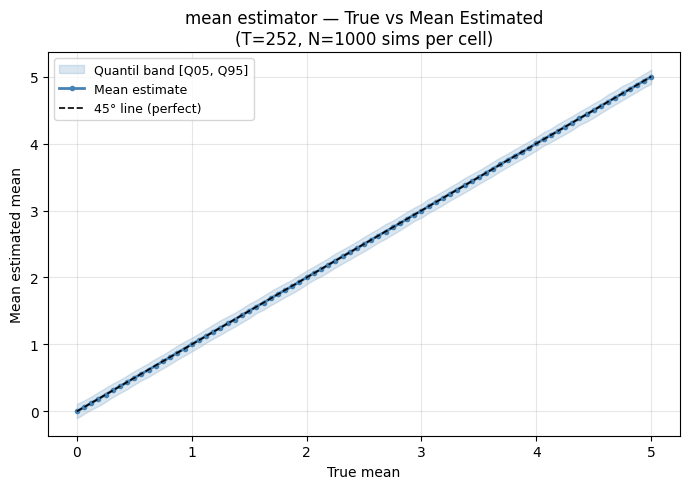

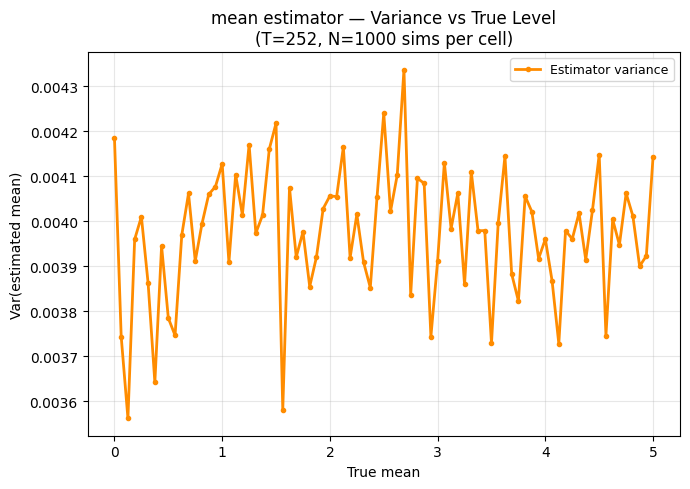

In [71]:
mean_panel = simulate_panel("mean", mean_df[mean_df["converged"]])
mean_agg   = aggregate_panel(mean_panel)
plot_experiment(mean_agg, param_name="mean")
#mean_reg   = regress_variance_on_moment(mean_agg)

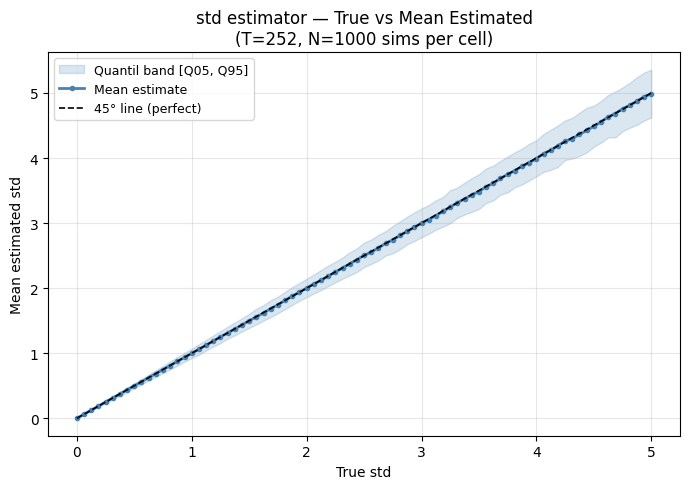

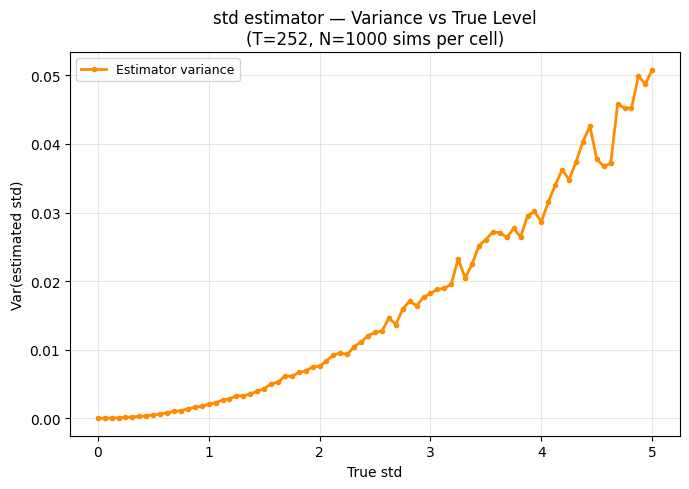

In [72]:
std_panel = simulate_panel("std", std_df[std_df["converged"]])
std_agg   = aggregate_panel(std_panel)
plot_experiment(std_agg, param_name="std")
#std_reg   = regress_variance_on_moment(std_agg)

Saved: skew_truevsmean.png


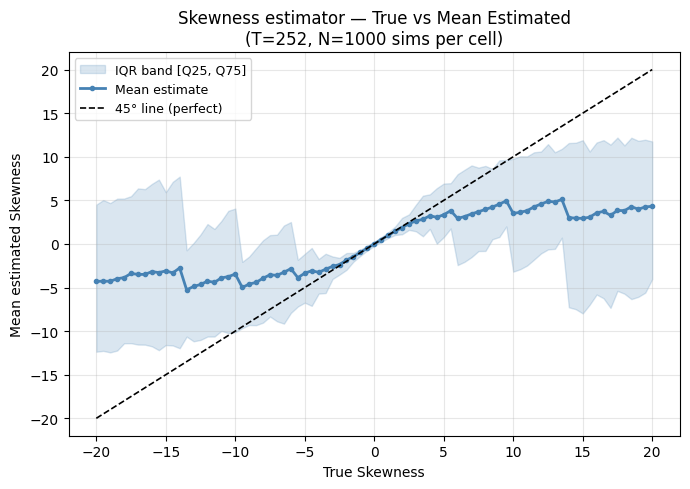

Saved: skew_variance.png


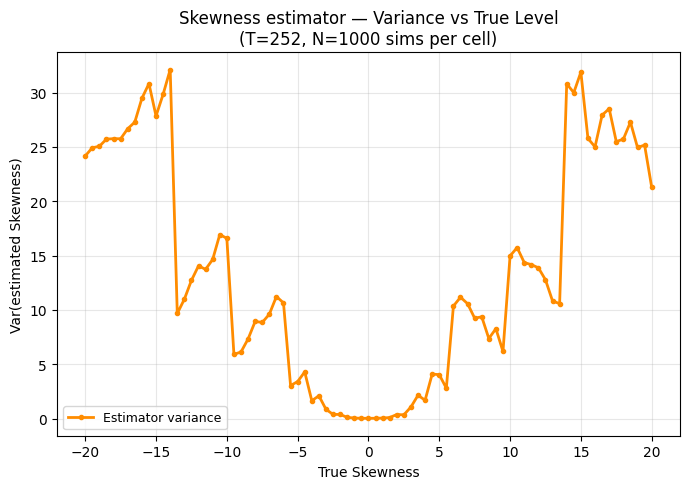

In [64]:
skew_panel = simulate_panel("skew", skew_df[skew_df["converged"]])
skew_agg   = aggregate_panel(skew_panel)
plot_experiment(skew_agg, param_name="Skewness", save_prefix="skew")
#skew_reg   = regress_variance_on_moment(skew_agg)

In [54]:
kurt_panel = simulate_panel("kurt", kurt_df[kurt_df["converged"]])
kurt_agg   = aggregate_panel(kurt_panel)
#kurt_reg   = regress_variance_on_moment(kurt_agg)

Saved: kurt_truevsmean.png


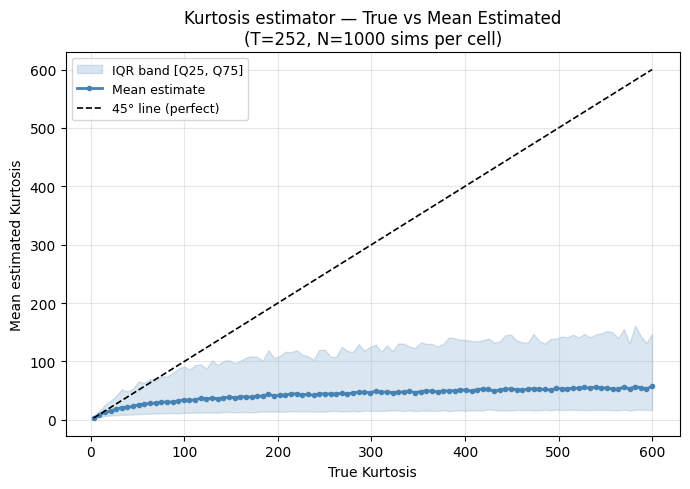

Saved: kurt_variance.png


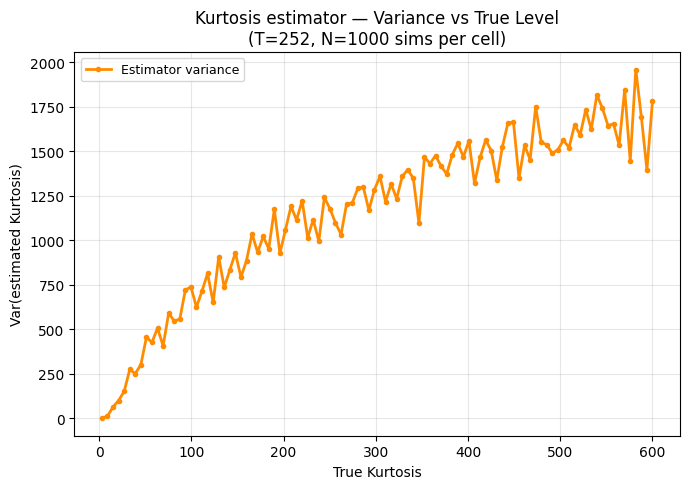

In [63]:
plot_experiment(kurt_agg, param_name="Kurtosis", save_prefix="kurt")